In [1]:
import re
import sys
import json
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from us import states
from census import Census

import useful
from setup import CENSUS_API_KEY

target_years = [2024]


In [7]:
def _tract_heating_data(target_states, target_years, loud=False):

    prefixes = {
        "B25003_001": "tot_occ",

        # heating fuel
        # NOTE: not renter specific
        "B25040_002": "u_gas",
        "B25040_003": "b_gas",
        "B25040_004": "elec",
        "B25040_005": "oil",
        "B25040_006": "coal",
        "B25040_007": "wood",
        "B25040_008": "solar",
        "B25040_009": "other",
        "B25040_010": "none"
    }
    
    output = useful.tract_states_years_variables(
        target_states, target_years, prefixes, 
        loud=loud)
      
    output = useful.aggregate(df=output, agg_name="other_", 
                       to_agg=["coal","solar","other","none"], drop=True)
    output.rename(columns={"other_": "other", "other__m": "other_m", "other__cv": "other_cv"}, inplace=True)
    output["most_heat"] = output[["u_gas", "b_gas", "elec", "oil", "wood", "other"]].idxmax(axis=1)

    output["most_heat_cv"] = [
        round((output.loc[idx, col+"_m"]/1.645)/output.loc[idx, col], 2) if output.loc[idx, col]!=0
        else 0

        for idx, col in enumerate(output["most_heat"])
        ]

    first_cols = ["year", "GEOID"]
    last_cols = [col for col in output.columns if col not in first_cols]
    output = output[first_cols + last_cols]

    return output

In [8]:
# blank cousub gdf with nems column
cousub_gdf =  gpd.GeoDataFrame(
    pd.concat([
        gpd.read_file('../shapes/tl_2022_09_cousub'),
        gpd.read_file('../shapes/tl_2022_23_cousub'), 
        gpd.read_file('../shapes/tl_2022_25_cousub'),
        gpd.read_file('../shapes/tl_2022_33_cousub'),
        gpd.read_file('../shapes/tl_2022_44_cousub'),
        gpd.read_file('../shapes/tl_2022_50_cousub'),
    ])
).merge(
    useful.cousub_states_years_variables(useful.target_states,target_years,{},loud=False), 
    on="GEOID", 
    how="inner"
).reset_index()



# tract heat gdf with no touch_nems column
tract_gdf = gpd.GeoDataFrame(
    pd.concat([
        gpd.read_file('../shapes/tl_2022_09_tract'),
        gpd.read_file('../shapes/tl_2022_23_tract'), 
        gpd.read_file('../shapes/tl_2022_25_tract'),
        gpd.read_file('../shapes/tl_2022_33_tract'),
        gpd.read_file('../shapes/tl_2022_44_tract'),
        gpd.read_file('../shapes/tl_2022_50_tract'),
    ])
).merge(
    _tract_heating_data(useful.target_states,target_years,loud=False), 
    on="GEOID", 
    how="inner"
).reset_index()

In [9]:
nems_cousub_gdf = cousub_gdf.loc[cousub_gdf['nems']==True][[
    'STATEFP', 'COUNTYFP', 'COUSUBFP', 'COUSUBNS', 'GEOID', 'NAME',
    'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CNECTAFP', 'NECTAFP',
    'NCTADVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON','geometry']].reset_index()

joined = gpd.sjoin(
    tract_gdf, 
    nems_cousub_gdf, 
    how='left', 
    predicate='intersects'
    )

tract_gdf['touch_nems'] = joined['index_right'].notna().groupby(level=0).any()
tract_gdf.rename(columns={'most_heat_cv':'most_cv', 'Energy_Burden':'burd',
       'Energy_Burden_elec':'burd_elec', 'Energy_Burden_gas':'burd_gas', 'Energy_Burden_other':'burd_other',
       'Avg_Energy_Cost':'cost_all', 'Avg_Energy_Cost_elec':'cost_elec', 'Avg_Energy_Cost_gas':'cost_gas',
       'Avg_Energy_Cost_other':'cost_other'},
                     inplace=True)
fuel_dict = {'u_gas': 'Utility gas', 'b_gas': 'Bottled gas', 'elec': 'Electricity', 'wood': 'Wood', 'oil': 'Oil', 'other': 'Other'}
tract_gdf['most_heat'] = tract_gdf['most_heat'].map(fuel_dict)


<Axes: >

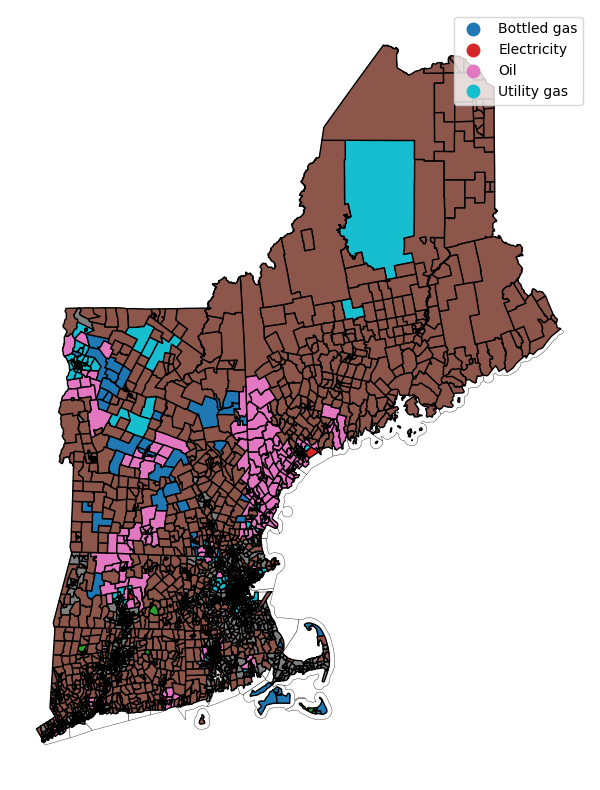

In [11]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')

tract_gdf.plot(ax=ax, facecolor='w', edgecolor='k', linewidth=0.25)
tract_gdf.loc[(tract_gdf['touch_nems']==True) & (tract_gdf['ALAND']>0)].plot(ax=ax, column='most_heat', edgecolor='k', legend=True)
tract_gdf.loc[(tract_gdf['touch_nems']==False) & (tract_gdf['ALAND']>0)].plot(ax=ax, column='most_heat', edgecolor='k')

In [2]:
gpd.GeoDataFrame(
    pd.concat([
        gpd.read_file('../shapes/tl_2022_09_tract'),
        gpd.read_file('../shapes/tl_2022_23_tract'), 
        gpd.read_file('../shapes/tl_2022_25_tract'),
        gpd.read_file('../shapes/tl_2022_33_tract'),
        gpd.read_file('../shapes/tl_2022_44_tract'),
        gpd.read_file('../shapes/tl_2022_50_tract'),
    ])
).reset_index().to_file('../shapes_out/ne_base_tract')